In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(42)
pd.set_option("display.precision", 3)


In [24]:
n = 6000

gender = RNG.choice(["Male", "Female"], size=n, p=[0.55, 0.45])
is_female = (gender == "Female").astype(float)

age = RNG.integers(21, 65, size=n)

income = RNG.normal(55000 - 9000 * is_female, 18000, size=n).clip(15000, None)
credit_score = RNG.normal(650 - 35 * is_female, 70, size=n).clip(300, 850)
years_employed = RNG.integers(0, 30, size=n)
debt_ratio = RNG.uniform(0, 0.6, size=n)

merit = (
    0.4 * (credit_score - 300) / 550
    + 0.3 * (income - 15000) / 200000
    + 0.2 * (years_employed / 30)
    - 0.3 * debt_ratio
)
merit_prob = 1 / (1 + np.exp(-8 * (merit - merit.mean())))

bias_penalty = np.where(gender == "Female", 0.12, 0.0)
approve_prob = np.clip(merit_prob - bias_penalty, 0.02, 0.98)
approved = RNG.binomial(1, approve_prob)

df = pd.DataFrame({
    "gender": gender,
    "age": age,
    "income": income.round(0),
    "credit_score": credit_score.round(0),
    "years_employed": years_employed,
    "debt_ratio": debt_ratio.round(3),
    "approved": approved,
})
df.head()


,gender,age,income,credit_score,years_employed,debt_ratio,approved
0,Female,43,17810.0,599.0,10,0.446,0
1,Male,41,82358.0,683.0,9,0.400,0
2,Female,24,64231.0,702.0,20,0.048,0
3,Female,26,52311.0,611.0,2,0.207,0
4,Male,47,57990.0,640.0,7,0.017,1


In [25]:
print(df.shape)
df.groupby("gender")["approved"].mean().rename("historical_approval_rate").to_frame()


(6000, 7)


,historical_approval_rate
gender,
Female,0.342
Male,0.543


In [26]:
FEATURES = ["age", "income", "credit_score", "years_employed", "debt_ratio"]
TARGET = "approved"
PROTECTED = "gender"

X = df[FEATURES]
y = df[TARGET]
g = df[PROTECTED]

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, g, test_size=0.25, random_state=42, stratify=df[[TARGET, PROTECTED]]
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Overall accuracy: {accuracy_score(y_test, y_pred):.3f}")


Overall accuracy: 0.673


In [27]:
def group_rates(y_true, y_pred, groups):
    """Return a per-group table of approval rate, TPR, FPR, accuracy."""
    rows = []
    for grp in sorted(groups.unique()):
        mask = groups == grp
        yt, yp = y_true[mask], y_pred[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows.append({
            "group": grp,
            "n": mask.sum(),
            "approval_rate": yp.mean(),
            "TPR": tp / (tp + fn) if (tp + fn) else np.nan,
            "FPR": fp / (fp + tn) if (fp + tn) else np.nan,
            "accuracy": accuracy_score(yt, yp),
        })
    return pd.DataFrame(rows).set_index("group")


def fairness_summary(y_true, y_pred, groups, label=""):
    rt = group_rates(y_true, y_pred, groups)
    dp_diff = rt["approval_rate"].max() - rt["approval_rate"].min()
    eo_diff = max(
        rt["TPR"].max() - rt["TPR"].min(),
        rt["FPR"].max() - rt["FPR"].min(),
    )
    print(f"--- {label} ---")
    display(rt)
    print(f"Demographic Parity difference: {dp_diff:.3f}")
    print(f"Equalized Odds difference:     {eo_diff:.3f}\n")
    return rt, dp_diff, eo_diff


rates_before, dp_before, eo_before = fairness_summary(
    y_test, pd.Series(y_pred, index=y_test.index), g_test, label="BEFORE mitigation"
)


--- BEFORE mitigation ---


,n,approval_rate,TPR,FPR,accuracy
group,,,,,
Female,664,0.306,0.502,0.204,0.696
Male,836,0.495,0.639,0.325,0.656


Demographic Parity difference: 0.189
Equalized Odds difference:     0.137



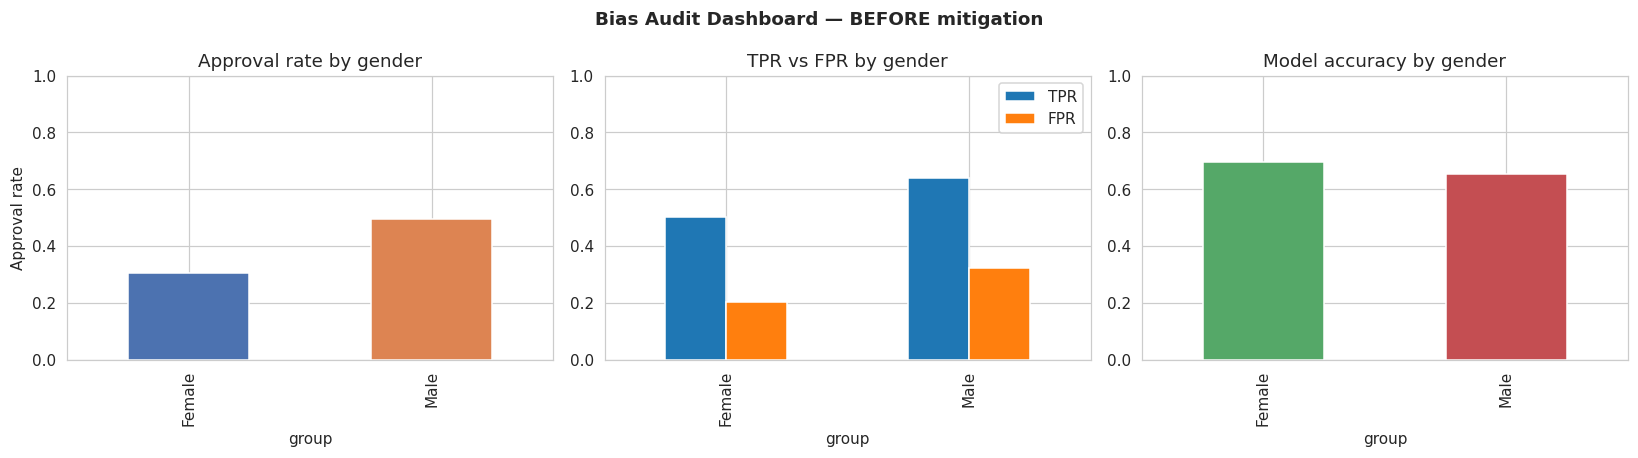

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

rates_before["approval_rate"].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Approval rate by gender")
axes[0].set_ylabel("Approval rate")
axes[0].set_ylim(0, 1)

rates_before[["TPR", "FPR"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("TPR vs FPR by gender")
axes[1].set_ylim(0, 1)

rates_before["accuracy"].plot(kind="bar", ax=axes[2], color=["#55A868", "#C44E52"])
axes[2].set_title("Model accuracy by gender")
axes[2].set_ylim(0, 1)

plt.suptitle("Bias Audit Dashboard — BEFORE mitigation", fontweight="bold")
plt.tight_layout()
plt.savefig("dashboard_before.png", bbox_inches="tight")
plt.show()


In [29]:
def compute_reweighing_weights(y, groups):
    df_w = pd.DataFrame({"y": y.values, "g": groups.values})
    n = len(df_w)
    weights = np.ones(n)
    for grp in df_w["g"].unique():
        for label in df_w["y"].unique():
            mask = (df_w["g"] == grp) & (df_w["y"] == label)
            p_expected = (df_w["g"] == grp).mean() * (df_w["y"] == label).mean()
            p_observed = mask.mean()
            if p_observed > 0:
                weights[mask.values] = p_expected / p_observed
    return weights


sample_w = compute_reweighing_weights(y_train, g_train)

clf_fair = LogisticRegression(max_iter=1000)
clf_fair.fit(X_train, y_train, sample_weight=sample_w)
y_pred_fair = clf_fair.predict(X_test)

print(f"Overall accuracy (mitigated): {accuracy_score(y_test, y_pred_fair):.3f}")


Overall accuracy (mitigated): 0.675


In [30]:
rates_after, dp_after, eo_after = fairness_summary(
    y_test, pd.Series(y_pred_fair, index=y_test.index), g_test, label="AFTER mitigation (reweighing)"
)


--- AFTER mitigation (reweighing) ---


,n,approval_rate,TPR,FPR,accuracy
group,,,,,
Female,664,0.315,0.511,0.213,0.693
Male,836,0.476,0.626,0.298,0.660


Demographic Parity difference: 0.161
Equalized Odds difference:     0.115



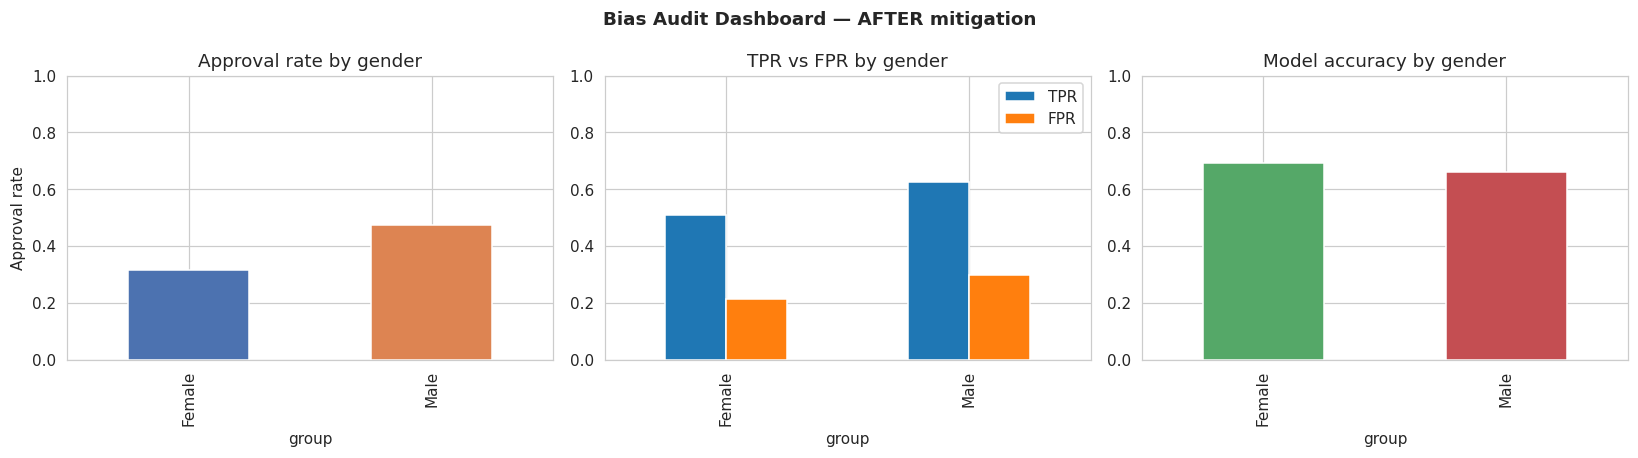

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

rates_after["approval_rate"].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Approval rate by gender")
axes[0].set_ylabel("Approval rate")
axes[0].set_ylim(0, 1)

rates_after[["TPR", "FPR"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("TPR vs FPR by gender")
axes[1].set_ylim(0, 1)

rates_after["accuracy"].plot(kind="bar", ax=axes[2], color=["#55A868", "#C44E52"])
axes[2].set_title("Model accuracy by gender")
axes[2].set_ylim(0, 1)

plt.suptitle("Bias Audit Dashboard — AFTER mitigation", fontweight="bold")
plt.tight_layout()
plt.savefig("dashboard_after.png", bbox_inches="tight")
plt.show()


In [32]:
comparison = pd.DataFrame({
    "Metric": [
        "Overall accuracy",
        "Demographic Parity difference",
        "Equalized Odds difference",
        "Approval rate - Male",
        "Approval rate - Female",
    ],
    "Before mitigation": [
        accuracy_score(y_test, y_pred),
        dp_before,
        eo_before,
        rates_before.loc["Male", "approval_rate"],
        rates_before.loc["Female", "approval_rate"],
    ],
    "After mitigation": [
        accuracy_score(y_test, y_pred_fair),
        dp_after,
        eo_after,
        rates_after.loc["Male", "approval_rate"],
        rates_after.loc["Female", "approval_rate"],
    ],
})
comparison["Change"] = comparison["After mitigation"] - comparison["Before mitigation"]
comparison


,Metric,Before mitigation,After mitigation,Change
0,Overall accuracy,0.673,0.675,0.001
1,Demographic Parity difference,0.189,0.161,-0.028
2,Equalized Odds difference,0.137,0.115,-0.022
3,Approval rate - Male,0.495,0.476,-0.019
4,Approval rate - Female,0.306,0.315,0.009


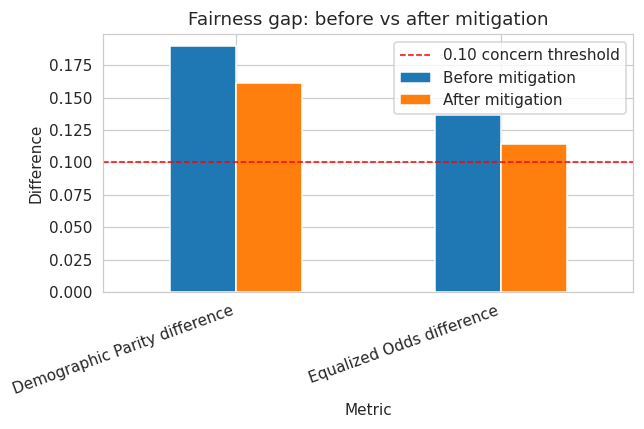

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
metrics_to_plot = ["Demographic Parity difference", "Equalized Odds difference"]
plot_df = comparison[comparison["Metric"].isin(metrics_to_plot)].set_index("Metric")
plot_df[["Before mitigation", "After mitigation"]].plot(kind="bar", ax=ax)
ax.axhline(0.1, color="red", linestyle="--", linewidth=1, label="0.10 concern threshold")
ax.set_ylabel("Difference")
ax.set_title("Fairness gap: before vs after mitigation")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("fairness_gap_comparison.png", bbox_inches="tight")
plt.show()
